# Motor Vehicle collisions

## Loading data and preview

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv(r"datasets\Motor_Vehicle_Collisions_-_Crashes_20260407.csv", delimiter=",")
data.head()

C:\Users\lucas\AppData\Local\Temp\ipykernel_24676\810263381.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r"datasets\Motor_Vehicle_Collisions_-_Crashes_20260407.csv", delimiter=",")


,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN
2,11/01/2023,1:29,BROOKLYN,11230.0,40.62179,-73.970024,"(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
3,06/29/2022,6:55,NaN,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN
4,09/21/2022,13:21,NaN,NaN,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2253192 entries, 0 to 2253191
Data columns (total 29 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   CRASH DATE                     object 
 1   CRASH TIME                     object 
 2   BOROUGH                        object 
 3   ZIP CODE                       object 
 4   LATITUDE                       float64
 5   LONGITUDE                      float64
 6   LOCATION                       object 
 7   ON STREET NAME                 object 
 8   CROSS STREET NAME              object 
 9   OFF STREET NAME                object 
 10  NUMBER OF PERSONS INJURED      float64
 11  NUMBER OF PERSONS KILLED       float64
 12  NUMBER OF PEDESTRIANS INJURED  int64  
 13  NUMBER OF PEDESTRIANS KILLED   int64  
 14  NUMBER OF CYCLIST INJURED      int64  
 15  NUMBER OF CYCLIST KILLED       int64  
 16  NUMBER OF MOTORIST INJURED     int64  
 17  NUMBER OF MOTORIST KILLED      int64  
 18  CO

## What month has the most accidents?

<Axes: title={'center': 'Number of Accidents per Month'}, xlabel='Month', ylabel='Number of Accidents'>

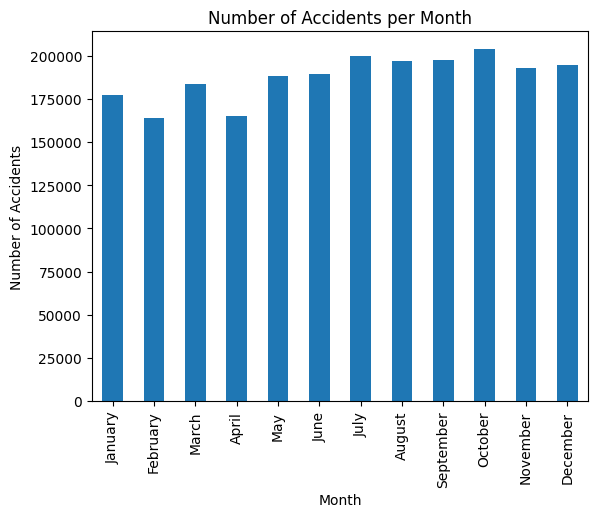

In [ ]:
# What month has the most accidents? We use the column "CRASH DATE" to extract the month and count the number of accidents for each month, create a bar plot comparing each month
data["CRASH DATE"] = pd.to_datetime(data["CRASH DATE"])
data["MONTH"] = data["CRASH DATE"].dt.month
month_counts = data["MONTH"].value_counts().sort_index()
# map each month to their name
month_counts.index = month_counts.index.map({1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June", 7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December"})
month_counts.plot(kind="bar", title="Number of Accidents per Month", xlabel="Month", ylabel="Number of Accidents")


## What time of day does crashes occur the most ? 

<Axes: title={'center': 'Number of Accidents per Hour'}, xlabel='Hour of Day', ylabel='Number of Accidents'>

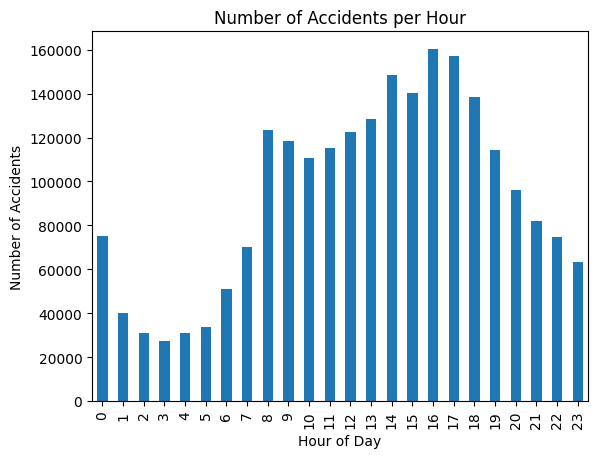

In [5]:
# What time of day has the most accidents? We use the column "CRASH TIME" to extract the hour and count the number of accidents for each hour, create a bar plot comparing each hour
data["CRASH TIME"] = pd.to_datetime(data["CRASH TIME"], format="%H:%M")
data["HOUR"] = data["CRASH TIME"].dt.hour
hour_counts = data["HOUR"].value_counts().sort_index()
hour_counts.plot(kind="bar", title="Number of Accidents per Hour", xlabel="Hour of Day", ylabel="Number of Accidents")

## Do some zipcodes have more crashes ? 

In [6]:
# Iterate over all values in zipcode columns and identify their types, only print unique types
unique_zipcode_types = data["ZIP CODE"].apply(type).unique()
print(unique_zipcode_types)

[<class 'float'> <class 'str'>]


In [7]:
# What zipcode has the most accidents? We use the column "ZIP CODE" to count the number of accidents for each zipcode, create a bar plot comparing each zipcode
data["ZIP CODE"] = (
    data["ZIP CODE"]
    .astype(str)                           # convert everything to string first
    .str.strip()                           # remove whitespace
    .replace("", float("nan"))             # turn empty strings into NaN
    .dropna()                              # drop NaNs
    .astype(float)                         # normalize "10001.0" strings
    .astype(int)                           # drop the decimal
    .astype(str)                           # convert to string
    .str.zfill(5)                          # restore leading zeros
)
zipcode_counts = data["ZIP CODE"].dropna().value_counts().sort_index()
zipcode_counts.plot(kind="bar", title="Number of Accidents per Zipcode", xlabel="Zipcode", ylabel="Number of Accidents")


IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

## When does the most violent crashes occur (meaning more people die or not only injured) ?

# Shooting Offenders

## Loading Data and Preview

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(r"datasets/Shooting_Offenders_(2006-Present)_20260407.csv")

In [3]:
data.head()

,INCIDENT_KEY,PERP_ID,PERP_AGE_GROUP,PERP_SEX,PERP_RACE
0,9953248,9953248-9042,18-24,MALE,BLACK
1,10137418,10137418-9127,25-44,MALE,BLACK
2,10137428,10137428-9147,UNKNOWN,UNKNOWN,UNKNOWN
3,10187494,10187494-9181,UNKNOWN,MALE,BLACK
4,10187494,10187494-9195,UNKNOWN,MALE,BLACK


## Comparing Genders

<Axes: title={'center': 'Number of Offenders by Gender'}, xlabel='Gender', ylabel='Number of Offenders'>

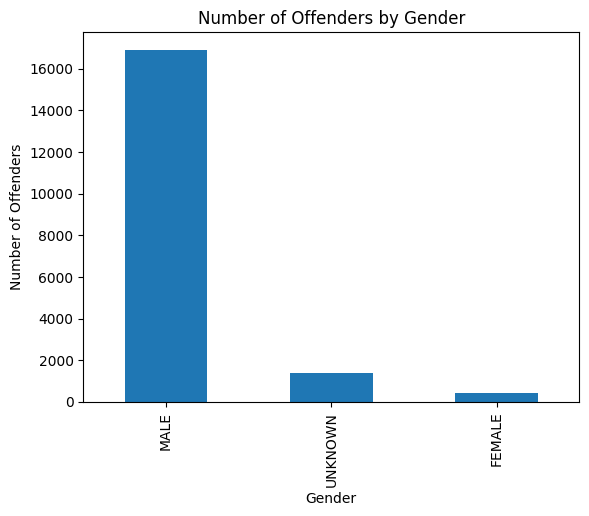

In [4]:
# Using the column PERP_SEX we counter the most frequent gender of the offenders, create a bar plot comparing each
gender_counts = data["PERP_SEX"].value_counts()
gender_counts.plot(kind="bar", title="Number of Offenders by Gender", xlabel="Gender", ylabel="Number of Offenders")


## Comparing Race

In [5]:
# checking the unique categroeis in PERP_RACE
unique_races = data["PERP_RACE"].unique()
print(unique_races)

['BLACK' 'UNKNOWN' 'WHITE HISPANIC' 'WHITE' 'BLACK HISPANIC'
 'ASIAN / PACIFIC ISLANDER' 'AMERICAN INDIAN/ALASKAN NATIVE']


<Axes: title={'center': 'Number of Offenders by Race'}, xlabel='Race', ylabel='Number of Offenders'>

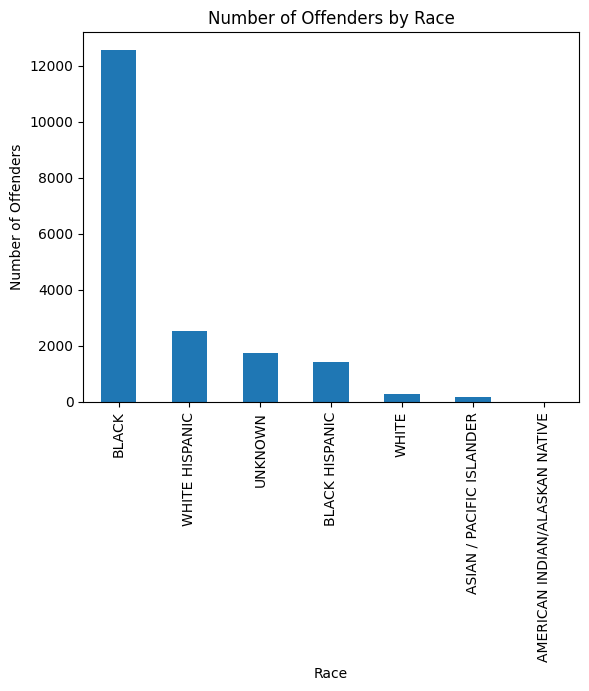

In [6]:
# Comapring the nuumbers of offenders for each race
race_counts = data["PERP_RACE"].value_counts()
race_counts.plot(kind="bar", title="Number of Offenders by Race", xlabel="Race", ylabel="Number of Offenders")


## Comparing age groups

In [ ]:
# printing the unique age groups from the column PERP_AGE_GROUP
unique_age_groups = data["PERP_AGE_GROUP"].unique()
print(unique_age_groups)

['18-24' '25-44' 'UNKNOWN' '<18' nan '45-64' '65+' '940' '224' '1020'
 '1028' '1822' '2021']


<Axes: title={'center': 'Number of Offenders by Age Group'}, xlabel='Age Group', ylabel='Number of Offenders'>

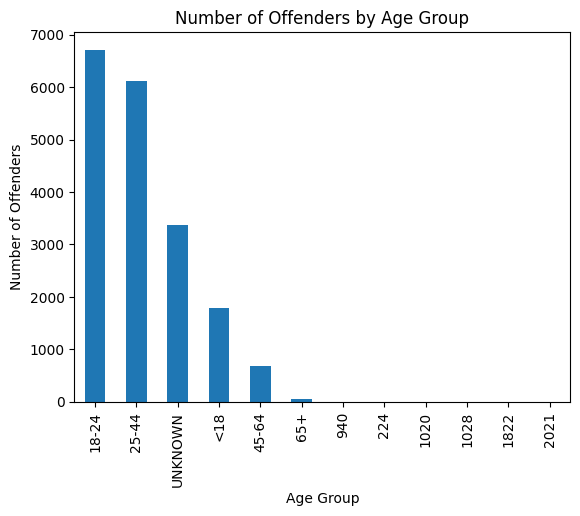

In [9]:
# Comparing the number of offenders for each age group
age_group_counts = data["PERP_AGE_GROUP"].value_counts()
age_group_counts.plot(kind="bar", title="Number of Offenders by Age Group", xlabel="Age Group", ylabel="Number of Offenders")

# New York City leading Causes of death

## Load and review Data

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
data = pd.read_csv(r'datasets\New_York_City_Leading_Causes_of_Death_20260407.csv')

In [12]:
data.head()

,Year,Leading Cause,Sex,Race Ethnicity,Deaths,Death Rate,Age Adjusted Death Rate
0,2021,Mental and Behavioral Disorders due to Acciden...,Male,Other Race/ Ethnicity,9,NaN,NaN
1,2021,All Other Causes,Female,Not Stated/Unknown,102,NaN,NaN
2,2021,Chronic Liver Diseases and Cirrhosis,Male,Not Stated/Unknown,16,NaN,NaN
3,2021,"Diseases of Heart (I00-I09, I11, I13, I20-I51)",Female,Hispanic,1409,111,95.5
4,2021,Influenza (Flu) and Pneumonia (J09-J18),Male,Not Stated/Unknown,16,NaN,NaN


## Comparing Number of Deaths by Disease

In [17]:
# Printing the unique values in the column "Leading Cause"
unique_causes = data["Leading Cause"].unique()
print(f'Number of unique causes: {len(unique_causes)}')
print(unique_causes)

Number of unique causes: 42
['Mental and Behavioral Disorders due to Accidental Poisoning and Other Psychoactive Substance Use (F11-F16, F18-F19, X40-X42, X44)'
 'All Other Causes' 'Chronic Liver Diseases and Cirrhosis'
 'Diseases of Heart (I00-I09, I11, I13, I20-I51)'
 'Influenza (Flu) and Pneumonia (J09-J18)'
 'Malignant Neoplasms (Cancer: C00-C97)' 'Covid-19'
 'Cerebrovascular Disease (Stroke: I60-I69)' "Alzheimer's Disease (G30)"
 'Diabetes Mellitus (E10-E14)'
 'Chronic Lower Respiratory Diseases (J40-J47)'
 'Essential Hypertension and Renal Diseases (I10, I12, I15)'
 'Mental and Behavioral Disorders due to Use of Alcohol (F10)'
 'Intentional Self-Harm (Suicide: U03, X60-X84, Y87.0)'
 'Accidents Except Drug Poisoning (V01-X39, X43, X45-X59, Y85-Y86)'
 'Septicemia'
 'Certain Conditions Originating in the Perinatal Period (P00-P96)'
 'Chronic Liver Disease and Cirrhosis (K70, K73-K74)'
 'Human Immunodeficiency Viruses Diseases'
 'Assault (Homicide: U01-U02, Y87.1, X85-Y09)'
 'Nephrit

float64
0       9.0
1     102.0
2      16.0
3    1409.0
4      16.0
Name: Deaths, dtype: float64


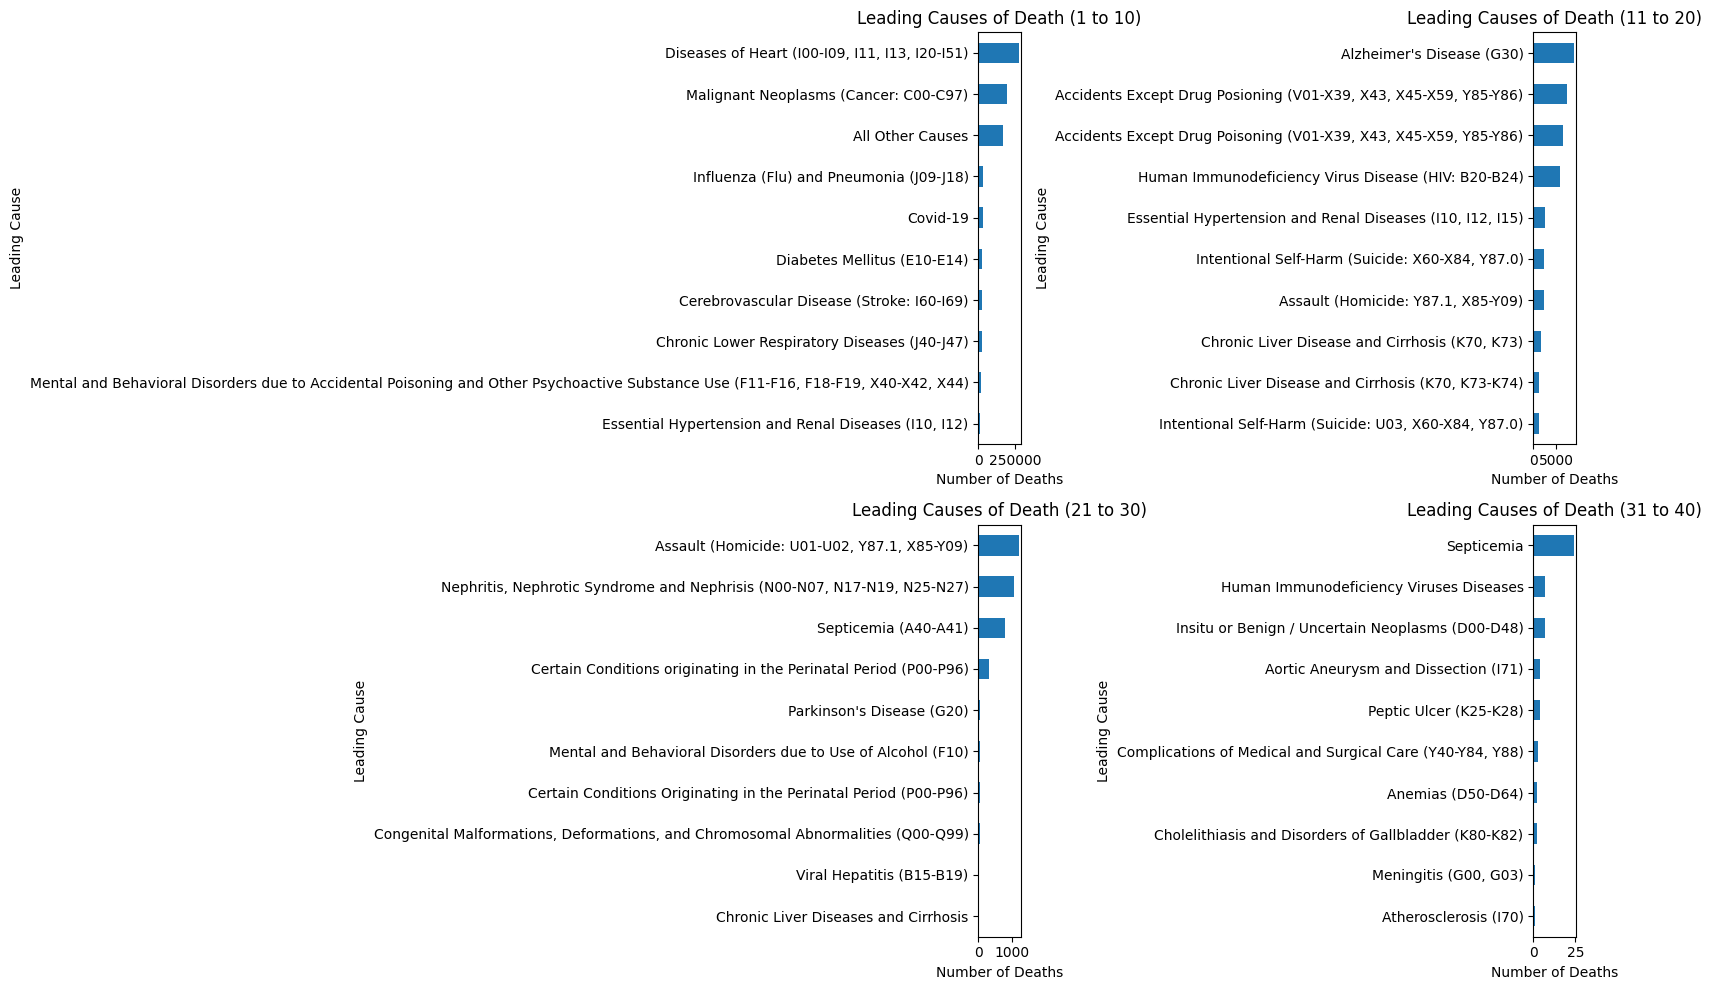

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Deaths to numeric
data["Deaths"] = (
    data["Deaths"]
    .astype(str)                   # make sure everything is string first
    .str.replace(",", "", regex=False)   # remove commas like "1,234"
    .str.strip()                   # remove extra spaces
)

data["Deaths"] = pd.to_numeric(data["Deaths"], errors="coerce")

# Optional: check whether conversion worked
print(data["Deaths"].dtype)
print(data["Deaths"].head())

# Drop rows where Deaths could not be converted
data_clean = data.dropna(subset=["Deaths"]).copy()

# Group and sum
cause_counts = (
    data_clean.groupby("Leading Cause")["Deaths"]
    .sum()
    .sort_values(ascending=False)
)

# 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

chunk_size = 10

for i in range(4):
    start = i * chunk_size
    end = start + chunk_size
    subset = cause_counts.iloc[start:end]

    subset.plot(
        kind="barh",
        ax=axes[i]
    )

    axes[i].set_title(f"Leading Causes of Death ({start + 1} to {min(end, len(cause_counts))})")
    axes[i].set_xlabel("Number of Deaths")
    axes[i].set_ylabel("Leading Cause")
    axes[i].invert_yaxis()  # largest in each chunk at top

plt.tight_layout()
plt.show()

# 120 years of OL history

* Link to dataset:
https://www.kaggle.com/datasets/muhammadehsan02/126-years-of-historical-olympic-dataset


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
data = pd.read_csv(r'datasets\athlete_events.csv')


In [3]:
data.columns

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='object')

In [4]:
#order the data by year
data = data.sort_values(by="Year")

In [ ]:
# compute the BMI in a new column
data["BMI"] = data["Weight"] / ((data["Height"] / 100) ** 2)

In [5]:
# check the range of year, age, weight and height
print(f"Year range: {data['Year'].min()} - {data['Year'].max()}")
print(f"Age range: {data['Age'].min()} - {data['Age'].max()}")
print(f"Weight range: {data['Weight'].min()} - {data['Weight'].max()}")
print(f"Height range: {data['Height'].min()} - {data['Height'].max()}")



Year range: 1896 - 2016
Age range: 10.0 - 97.0
Weight range: 25.0 - 214.0
Height range: 127.0 - 226.0


In [6]:
# check the number of unique sports and events
print(f"Number of unique sports: {data['Sport'].nunique()}")
print(f"Number of unique events: {data['Event'].nunique()}")

Number of unique sports: 66
Number of unique events: 765


In [9]:
# check the different types of sports
data["Sport"].unique()

array(['Gymnastics', 'Athletics', 'Shooting', 'Tennis', 'Fencing',
       'Swimming', 'Cycling', 'Weightlifting', 'Wrestling', 'Croquet',
       'Water Polo', 'Sailing', 'Rowing', 'Tug-Of-War', 'Polo',
       'Equestrianism', 'Rugby', 'Football', 'Archery', 'Cricket', 'Golf',
       'Basque Pelota', 'Boxing', 'Lacrosse', 'Diving', 'Roque', 'Hockey',
       'Figure Skating', 'Jeu De Paume', 'Motorboating', 'Racquets',
       'Art Competitions', 'Modern Pentathlon', 'Ice Hockey',
       'Cross Country Skiing', 'Nordic Combined', 'Alpinism', 'Bobsleigh',
       'Military Ski Patrol', 'Ski Jumping', 'Curling', 'Speed Skating',
       'Skeleton', 'Canoeing', 'Alpine Skiing', 'Basketball', 'Handball',
       'Aeronautics', 'Biathlon', 'Volleyball', 'Luge', 'Judo',
       'Synchronized Swimming', 'Rhythmic Gymnastics', 'Table Tennis',
       'Freestyle Skiing', 'Badminton', 'Baseball',
       'Short Track Speed Skating', 'Softball', 'Beach Volleyball',
       'Snowboarding', 'Triathlon', 'Tae

In [10]:
# check the different types of medals and their counts
data["Medal"].value_counts()

Medal
Gold      13372
Bronze    13295
Silver    13116
Name: count, dtype: int64

In [11]:
# check the different types of events
data["Event"].unique()

array(["Gymnastics Men's Pommelled Horse", "Athletics Men's Triple Jump",
       "Athletics Men's Long Jump", "Gymnastics Men's Horse Vault",
       "Gymnastics Men's Parallel Bars",
       "Gymnastics Men's Parallel Bars, Teams",
       "Gymnastics Men's Horizontal Bar",
       "Gymnastics Men's Horizontal Bar, Teams", "Gymnastics Men's Rings",
       "Athletics Men's 1,500 metres",
       "Shooting Men's Military Rifle, 200 metres",
       "Athletics Men's Marathon", "Athletics Men's 800 metres",
       "Tennis Men's Doubles", "Tennis Men's Singles",
       "Fencing Men's Foil, Individual",
       "Swimming Men's 1,200 metres Freestyle",
       "Swimming Men's 500 metres Freestyle",
       "Athletics Men's Discus Throw", "Cycling Men's 100 kilometres",
       "Cycling Men's 333 metres Time Trial",
       "Shooting Men's Military Pistol, 25 metres",
       "Shooting Men's Muzzle-Loading Pistol, 25 metres",
       "Cycling Men's Road Race, Individual",
       "Cycling Men's 12-Hours Ra

In [12]:
# check the different type of seasons
data["Season"].unique()

array(['Summer', 'Winter'], dtype=object)

In [15]:
# check NOC
data["NOC"].unique()
print(f"Number of unique NOCs: {data['NOC'].nunique()}")

Number of unique NOCs: 230


## How has age, height, weight change for men and women over the years across all sports?

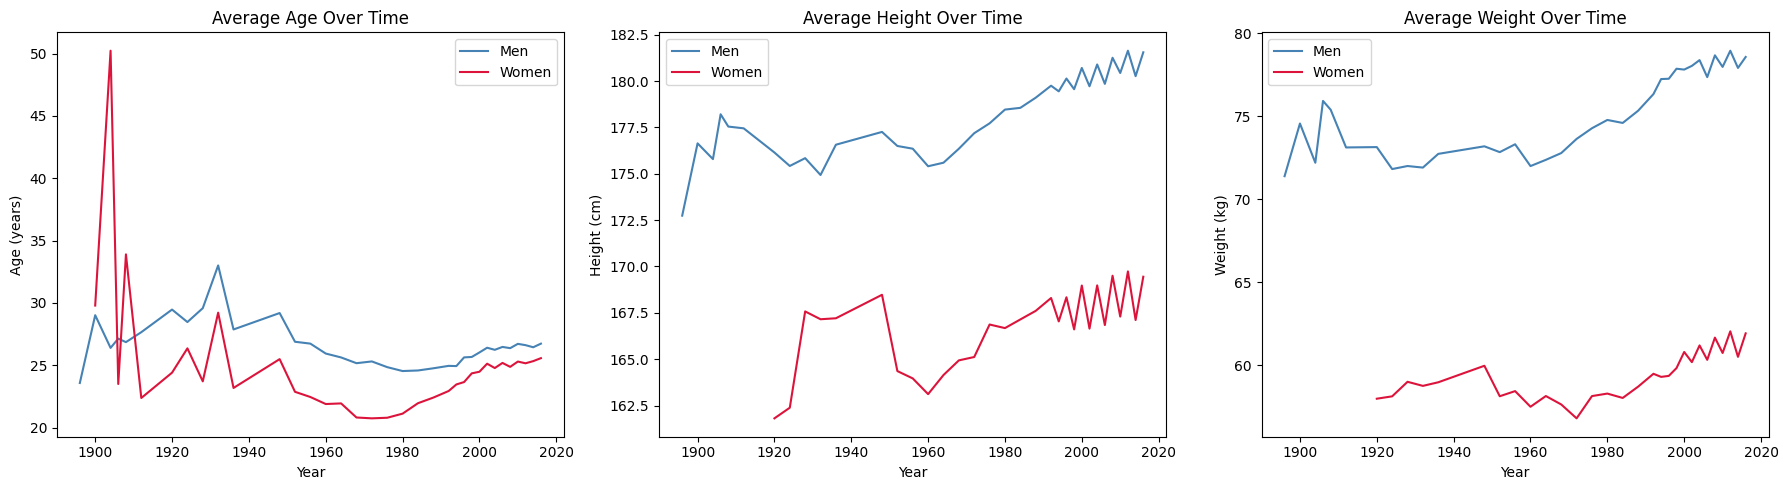

In [8]:
# Plot the age, height and weight of the athletes over time, men and women separate on their sepearate subplots. 
# Use a line plot with year on the x-axis and age, height and weight on the y-axis. If there are multiple athletes in the same year, take the average of their age, height and weight for that year.    
women_age = data[data["Sex"] == "F"].groupby("Year")["Age"].mean()
women_height = data[data["Sex"] == "F"].groupby("Year")["Height"].mean()
women_weight = data[data["Sex"] == "F"].groupby("Year")["Weight"].mean()

men_age = data[data["Sex"] == "M"].groupby("Year")["Age"].mean()
men_height = data[data["Sex"] == "M"].groupby("Year")["Height"].mean()
men_weight = data[data["Sex"] == "M"].groupby("Year")["Weight"].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age
men_age.plot(ax=axes[0], label="Men", color="steelblue")
women_age.plot(ax=axes[0], label="Women", color="crimson")
axes[0].set_title("Average Age Over Time")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Age (years)")
axes[0].legend()

# Height
men_height.plot(ax=axes[1], label="Men", color="steelblue")
women_height.plot(ax=axes[1], label="Women", color="crimson")
axes[1].set_title("Average Height Over Time")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Height (cm)")
axes[1].legend()

# Weight
men_weight.plot(ax=axes[2], label="Men", color="steelblue")
women_weight.plot(ax=axes[2], label="Women", color="crimson")
axes[2].set_title("Average Weight Over Time")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Weight (kg)")
axes[2].legend()

plt.tight_layout()
plt.show()

* For age there seem to be some oscillations and there is no clear visual trend
* For height and weight we see clear upgoing trends
* For Height we see men going from 172.5 cm to above 180 cm and women going from 162.5 cm to 167.5 cm
* For Weight we see women going from just below 60 kg to around 62 kg and men going from 72 kg to 77 kg


## What country has won the most medals ? 

In [16]:
# What country has won the most gold, silver, bronze and total medals ? We sort these into individual dataframes and print the top 10 for each 

gold_medals = data[data["Medal"] == "Gold"]
gold_medal_counts = gold_medals["NOC"].value_counts()

silver_medals = data[data["Medal"] == "Silver"]
silver_medal_counts = silver_medals["NOC"].value_counts()

bronze_medals = data[data["Medal"] == "Bronze"]
bronze_medal_counts = bronze_medals["NOC"].value_counts()

total_medal_counts = data[data["Medal"].notna()]["NOC"].value_counts()
print("Top 10 countries by Gold Medals:")
print(gold_medal_counts.head(10))
print("\nTop 10 countries by Silver Medals:")
print(silver_medal_counts.head(10))
print("\nTop 10 countries by Bronze Medals:")
print(bronze_medal_counts.head(10))
print("\nTop 10 countries by Total Medals:")
print(total_medal_counts.head(10))

Top 10 countries by Gold Medals:
NOC
USA    2638
URS    1082
GER     745
GBR     678
ITA     575
FRA     501
SWE     479
CAN     463
HUN     432
GDR     397
Name: count, dtype: int64

Top 10 countries by Silver Medals:
NOC
USA    1641
GBR     739
URS     732
GER     674
FRA     610
ITA     531
SWE     522
AUS     455
CAN     438
RUS     367
Name: count, dtype: int64

Top 10 countries by Bronze Medals:
NOC
USA    1358
GER     746
URS     689
FRA     666
GBR     651
SWE     535
ITA     531
AUS     517
CAN     451
FIN     432
Name: count, dtype: int64

Top 10 countries by Total Medals:
NOC
USA    5637
URS    2503
GER    2165
GBR    2068
FRA    1777
ITA    1637
SWE    1536
CAN    1352
AUS    1320
RUS    1165
Name: count, dtype: int64


## What sport is Denmark the best at ? 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## How has the biological markers changed for men and women across different sports changed over the years ? 

In [18]:
import os

output_dir = "sports_plots"
os.makedirs(output_dir, exist_ok=True)

sports = data["Sport"].unique()

for sport in sports:
    sport_data = data[data["Sport"] == sport]
    
    men = sport_data[sport_data["Sex"] == "M"]
    women = sport_data[sport_data["Sex"] == "F"]
    
    men_age = men.groupby("Year")["Age"].mean()
    men_height = men.groupby("Year")["Height"].mean()
    men_weight = men.groupby("Year")["Weight"].mean()
    
    women_age = women.groupby("Year")["Age"].mean()
    women_height = women.groupby("Year")["Height"].mean()
    women_weight = women.groupby("Year")["Weight"].mean()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Sport: {sport}", fontsize=14, fontweight="bold")
    
    men_age.plot(ax=axes[0], label="Men", color="steelblue")
    women_age.plot(ax=axes[0], label="Women", color="crimson")
    axes[0].set_title("Average Age Over Time")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Age (years)")
    axes[0].legend()

    men_height.plot(ax=axes[1], label="Men", color="steelblue")
    women_height.plot(ax=axes[1], label="Women", color="crimson")
    axes[1].set_title("Average Height Over Time")
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("Height (cm)")
    axes[1].legend()

    men_weight.plot(ax=axes[2], label="Men", color="steelblue")
    women_weight.plot(ax=axes[2], label="Women", color="crimson")
    axes[2].set_title("Average Weight Over Time")
    axes[2].set_xlabel("Year")
    axes[2].set_ylabel("Weight (kg)")
    axes[2].legend()
    
    plt.tight_layout()
    
    # Sanitize sport name for use as filename
    safe_name = sport.replace(" ", "_").replace("/", "-")
    fig.savefig(os.path.join(output_dir, f"{safe_name}.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)

print(f"Saved {len(sports)} plots to '{output_dir}/'")

Saved 66 plots to 'sports_plots/'


## Is there a pattern with regards to biological markers such as age, weight and height across in those who win gold in different sports?

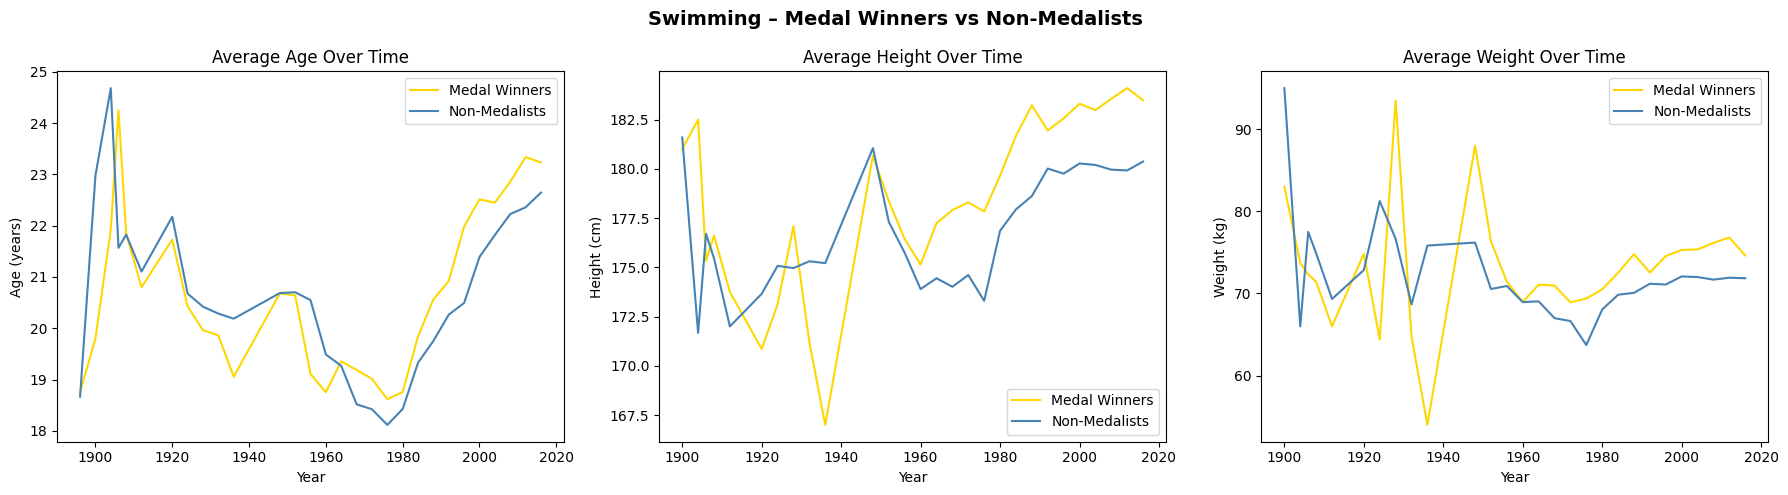

In [21]:
swimming_data = data[data["Sport"] == "Swimming"]
medal_winners = swimming_data[swimming_data["Medal"].notna()]
non_medalists = swimming_data[swimming_data["Medal"].isna()]

# Average by year
medal_age = medal_winners.groupby("Year")["Age"].mean()
medal_height = medal_winners.groupby("Year")["Height"].mean()
medal_weight = medal_winners.groupby("Year")["Weight"].mean()

non_medal_age = non_medalists.groupby("Year")["Age"].mean()
non_medal_height = non_medalists.groupby("Year")["Height"].mean()
non_medal_weight = non_medalists.groupby("Year")["Weight"].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Swimming – Medal Winners vs Non-Medalists", fontsize=14, fontweight="bold")

# Age
medal_age.plot(ax=axes[0], label="Medal Winners", color="gold")
non_medal_age.plot(ax=axes[0], label="Non-Medalists", color="steelblue")
axes[0].set_title("Average Age Over Time")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Age (years)")
axes[0].legend()

# Height
medal_height.plot(ax=axes[1], label="Medal Winners", color="gold")
non_medal_height.plot(ax=axes[1], label="Non-Medalists", color="steelblue")
axes[1].set_title("Average Height Over Time")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Height (cm)")
axes[1].legend()

# Weight
medal_weight.plot(ax=axes[2], label="Medal Winners", color="gold")
non_medal_weight.plot(ax=axes[2], label="Non-Medalists", color="steelblue")
axes[2].set_title("Average Weight Over Time")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Weight (kg)")
axes[2].legend()

plt.tight_layout()
plt.show()

* We see there has been a consistency in the mdeal winners since the 1960s have been on average slightly older, slightly taller, and weighted mre than their competition at least in swimming

* Plot the the world countries and their color intentisyt black, bronze, silver, gold based on how many medals they won of each over time
* Investigate if there is a correlation between performance at the olympics and the wellbeing of citizens in the country or any other metric. number of residents, number of people participating in sports, capital per person
* What country has best performing women ? Best performing men ? 
* How has BMI changed over time ? 
* How has the variance changed over time ? Are athletes more uniform ? 
* How has the ratio of medals won by each country changed over time ? Is someone upcoming ? And could it be raletd to any specific measurebale factor ? 

# Rental appartments in NYC

* Dataset 1 contains housing violations issued against the landlord. These are based in finding problems with the housing that can be hazardous towards the tenant

* Dataset 2 contains evictions, removal of tenants from their homes. Where, when and what type of eviction happened

* Dataset 3 contains neighbourhood tabulation areas is just a mao. It's NYC carved into 262 neighbourhood sized chunks. It allows for color coding the map

* Together all 3 dataset can be used to compare violations with evictions in different neighbourshoods

# Links to previous years projects

* https://www.youtube.com/watch?app=desktop&v=VFlAILi6xOs
* https://nestorbonjorn.github.io/DTU_SocialDataProject/
* https://project-not-cool.netlify.app/outline/
* https://www.youtube.com/watch?v=YtY5LW9TEuA
* https://prezi.com/p/hzu_nctnn14v/project-a-hugmynd-2/


* Do the same storytelling type as in assigment 2. Linear media storytelling something
* Have at least 3 visualizations
* Include spatial and temporal data
* Potentially merge 2 datasets for new findings